# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
%matplotlib inline

In [2]:
# Read in the data set
# Using a try-except block to catch and handle potential errors.
try:
    # Read in the 'ames.csv' file.
    ames_df = pd.read_csv('ames.csv')
# Using 'except FileNotFoundError' to handle the case where the
# 'ames.csv' file does not exist and display an informative message.
except FileNotFoundError:
    print("Error: ames.csv not found.")
    # Exit the program if the file is not found.
    exit()

# Display the first 5 observations.
ames_df.head()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


In [3]:
# Clean and pre-process the data if neccessary
# Get the shape of the data.
print(ames_df.shape)

# Get the number of missing data values per column.
missing_values_count = ames_df.isnull().sum()
print(missing_values_count)

(2930, 14)
Year_Built        0
Year_Remod_Add    0
Total_Bsmt_SF     0
First_Flr_SF      0
Second_Flr_SF     0
Gr_Liv_Area       0
Full_Bath         0
Half_Bath         0
Bedroom_AbvGr     0
Kitchen_AbvGr     0
TotRms_AbvGrd     0
Fireplaces        0
Garage_Area       0
Sale_Price        0
dtype: int64


In [4]:
# Checking for duplicates.
duplicate_before = ames_df.duplicated().sum()
print("Duplicates found: ", duplicate_before)

# Drop any duplicates.
ames_df = ames_df.drop_duplicates()

# Checking that there are no more duplicates.
duplicate_after = ames_df.duplicated().sum()
print("Removing duplicates.\nDuplicates left: ", duplicate_after)

Duplicates found:  7
Removing duplicates.
Duplicates left:  0


There are no missing values in the dataset.   
The data type is consistent throughout the dataset, the datatype of all the data is integer.   
All duplicates have been removed.

In [5]:
ames_df.describe()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
count,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000,2923.000000
mean,1971.310298,1984.251112,1051.796100,1159.433459,334.915840,1499.037290,1.563804,0.379063,2.852549,1.043106,6.442696,0.599042,472.693124,180793.054396
std,30.255062,20.865723,440.469747,392.138899,427.361419,504.915043,0.549049,0.501196,0.823892,0.211387,1.573561,0.647238,214.870790,79915.178796
min,1872.000000,1950.000000,0.000000,334.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,12789.000000
25%,1954.000000,1965.000000,793.000000,876.000000,0.000000,1125.500000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,320.000000,129500.000000
50%,1973.000000,1993.000000,990.000000,1082.000000,0.000000,1442.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,480.000000,160000.000000
75%,2001.000000,2004.000000,1302.000000,1384.000000,703.500000,1742.500000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,576.000000,213500.000000
max,2010.000000,2010.000000,6110.000000,5095.000000,2065.000000,5642.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,1488.000000,755000.000000


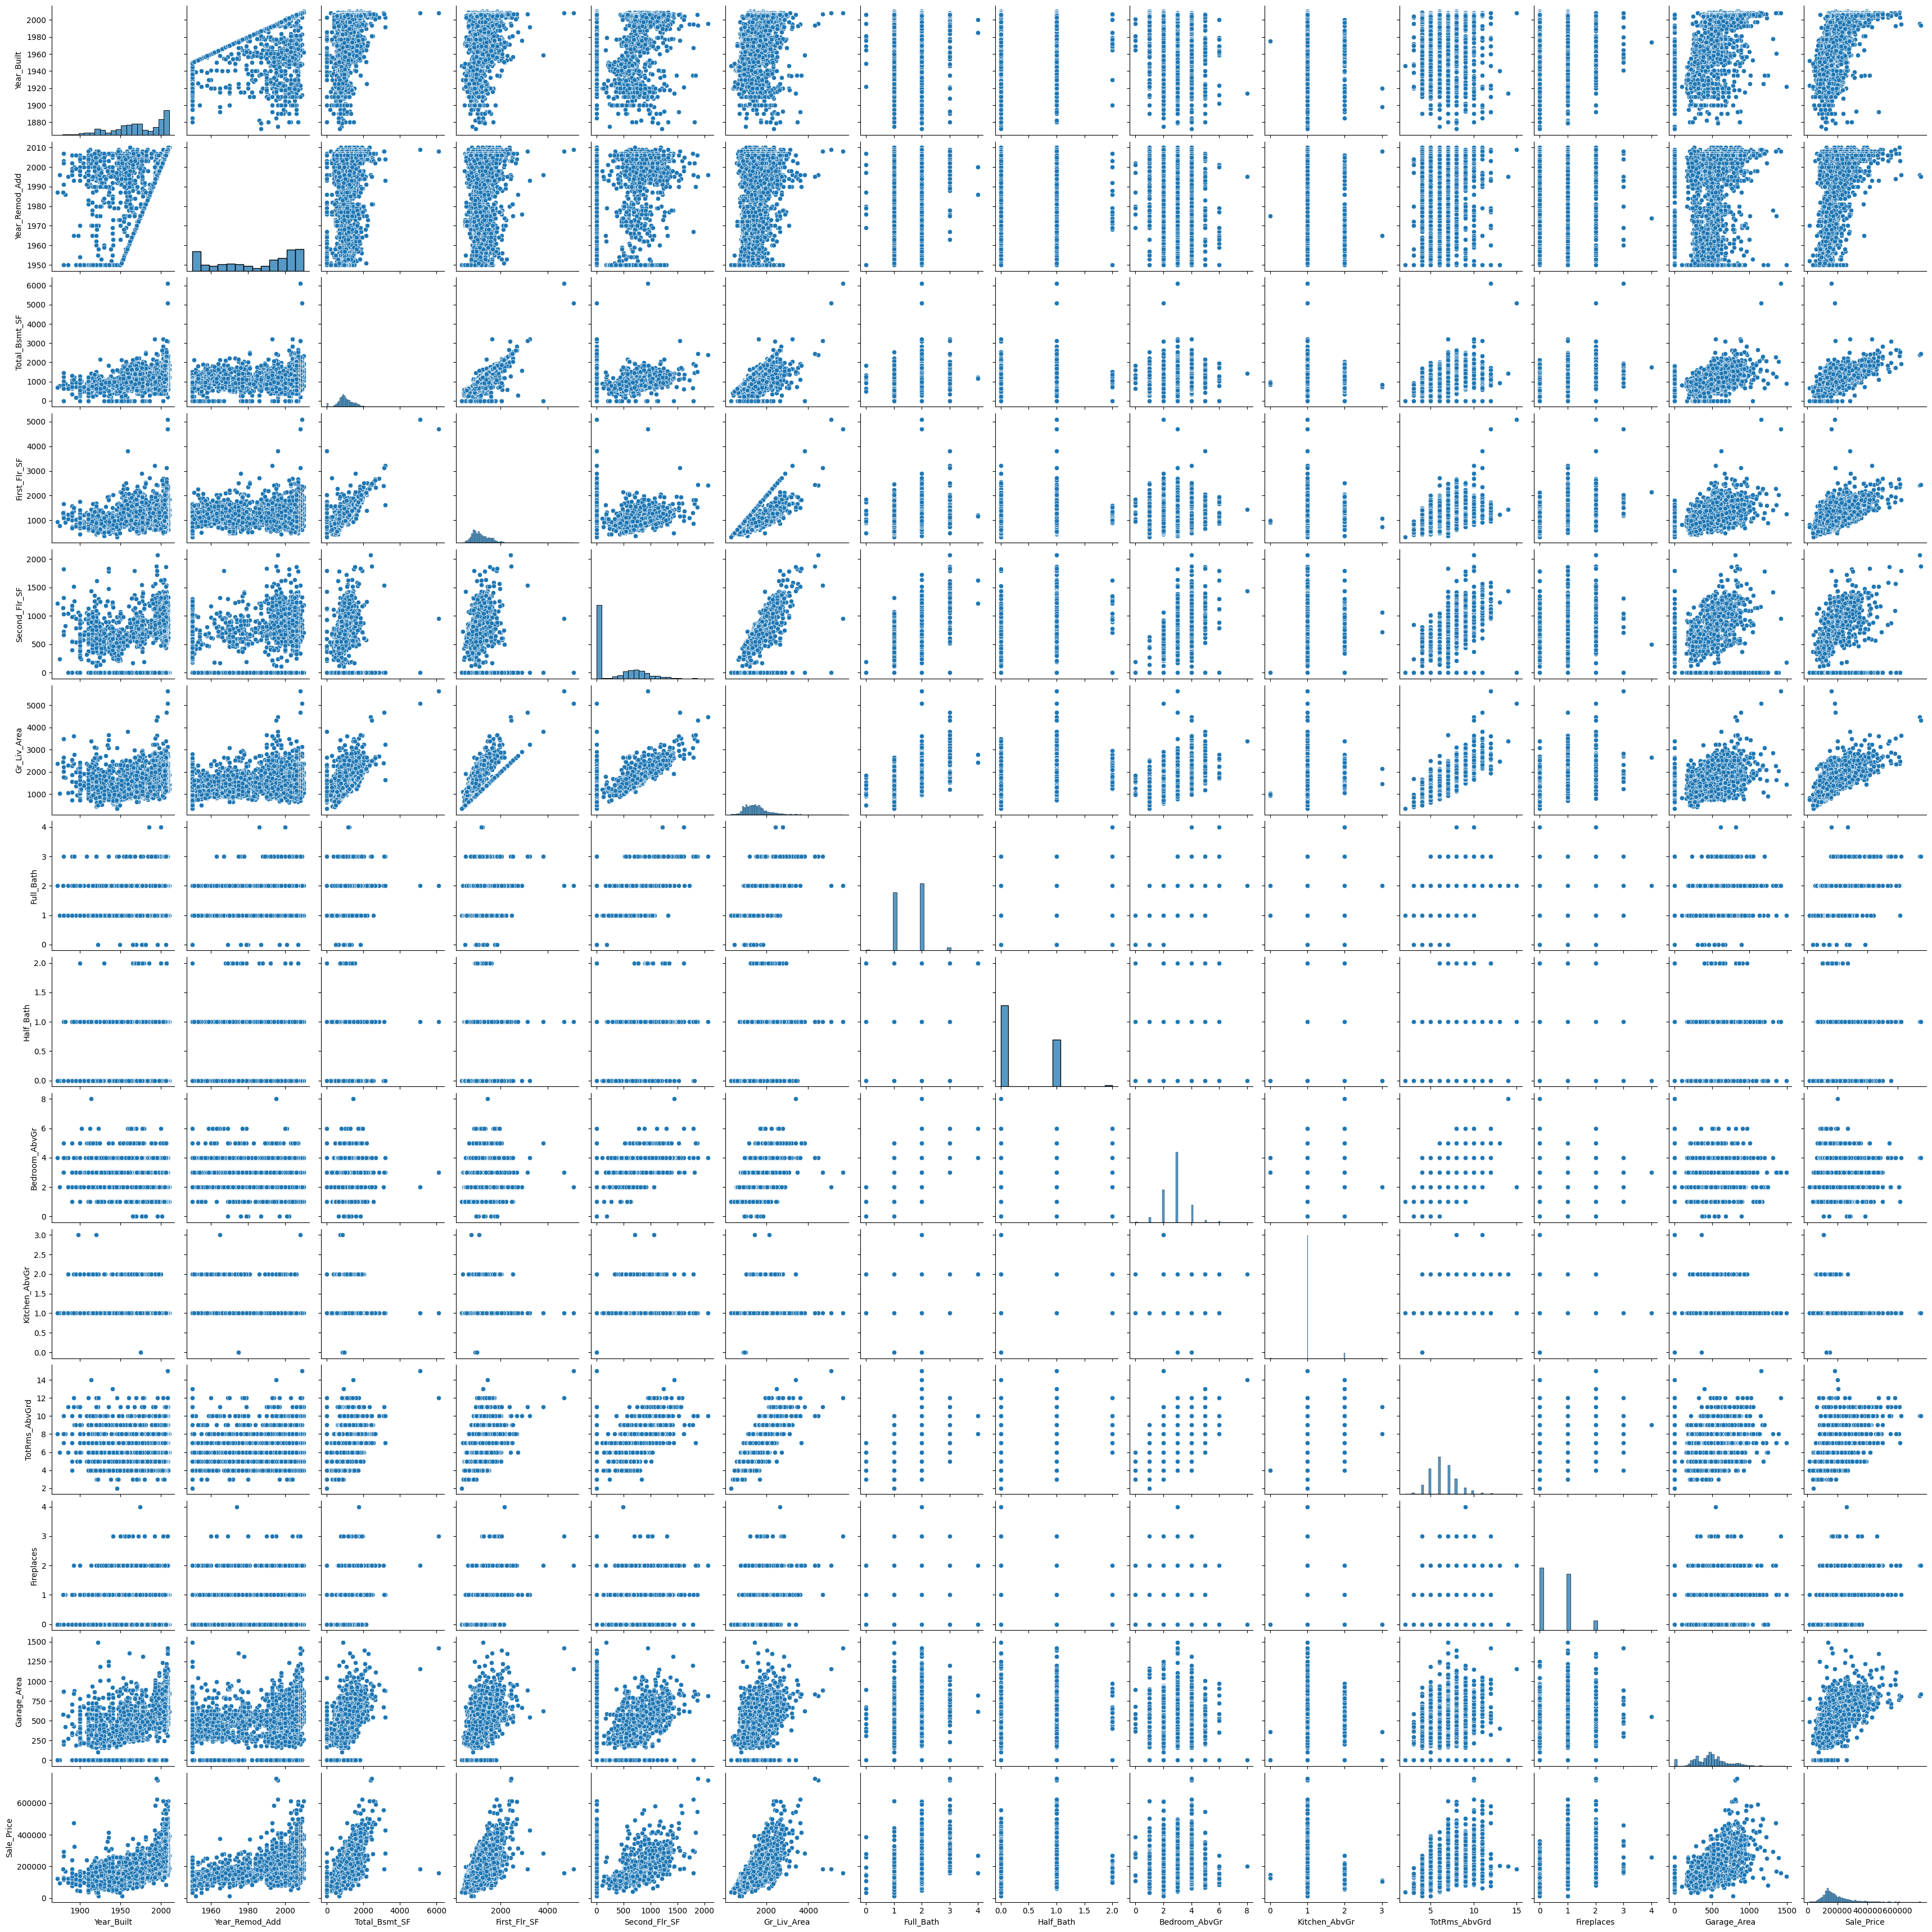

In [6]:
# Explore the data with visualisations such as histograms and correlation matrices
# Plot the distribution of the data.
sns.pairplot(data=ames_df)

<Axes: >

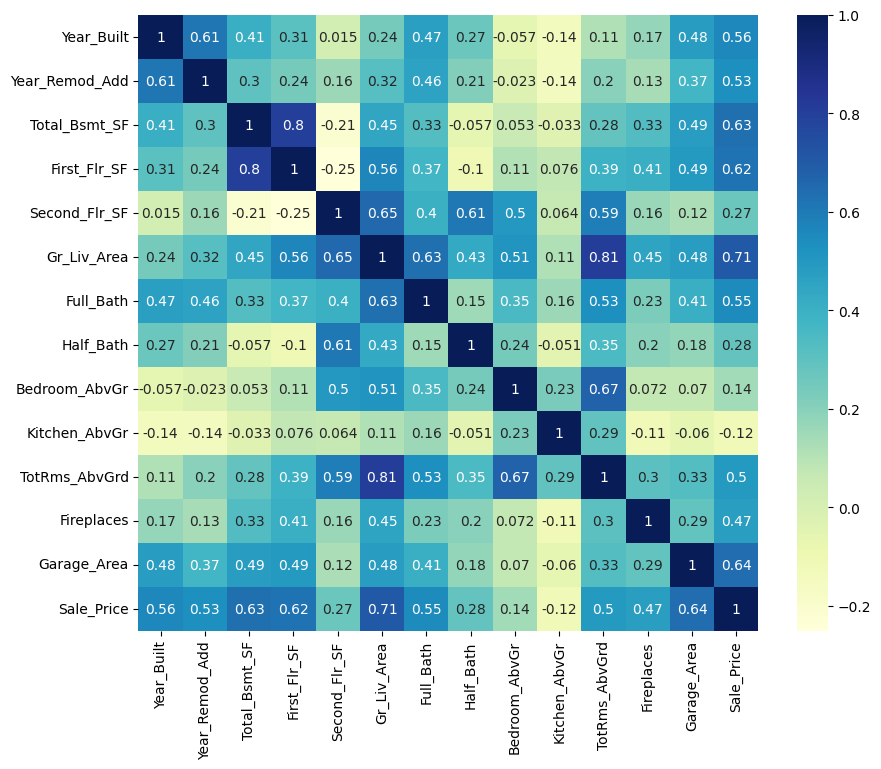

In [7]:
# Plot the heatmap to visualize correlations.
plt.figure(figsize=(10,8))
sns.heatmap(ames_df.corr(), annot=True,cmap='YlGnBu' )

From the above heatmap, we can see that there is a strong positive correlation between the size of above grade, ground living area in square feet 'Gr_Liv_Area' and the target variable, 'Sale_Price' (with a correlation value of 0.71). The scatterplot above also showed that visually, a linear relationship exists between the two.    
There is also a strong positive correlation between the size of garage in square feet 'Garage_Area' and the target variable, 'Sale_Price' (with a correlation value of 0.64).

Other variables, with strong positive correlations with 'Sale_Price' are the total size of basement area in square feet 'Total_Bsmt_SF' (with a correlation value of 0.63) and the size of the first floor in square feet 'First_Flr_SF' (with a correlation value of 0.62).

It is clear that the variables with the highest correlations with the sale price of the house in dollars (Sale_Price) are 'Gr_Liv_Area' and 'Garage_Area'. Therefore the multiple linear regression model to predict the sale prices will be based on the 'Gr_Liv_Area' and 'Garage_Area' variables.

In [8]:
# Split the independent variables from the dependent variable
# Selecting the 'Sale_Price' column as the target vector (y) and the
# 'Gr_Liv_Area' column and 'Garage_Area' column as the feature matrix (X).
X = ames_df[['Gr_Liv_Area', 'Garage_Area']]
y = ames_df['Sale_Price']

In [9]:
print("\nShape of independent variables (X):", X.shape)
print("Shape of dependent variable (y):", y.shape)


Shape of independent variables (X): (2923, 2)
Shape of dependent variable (y): (2923,)


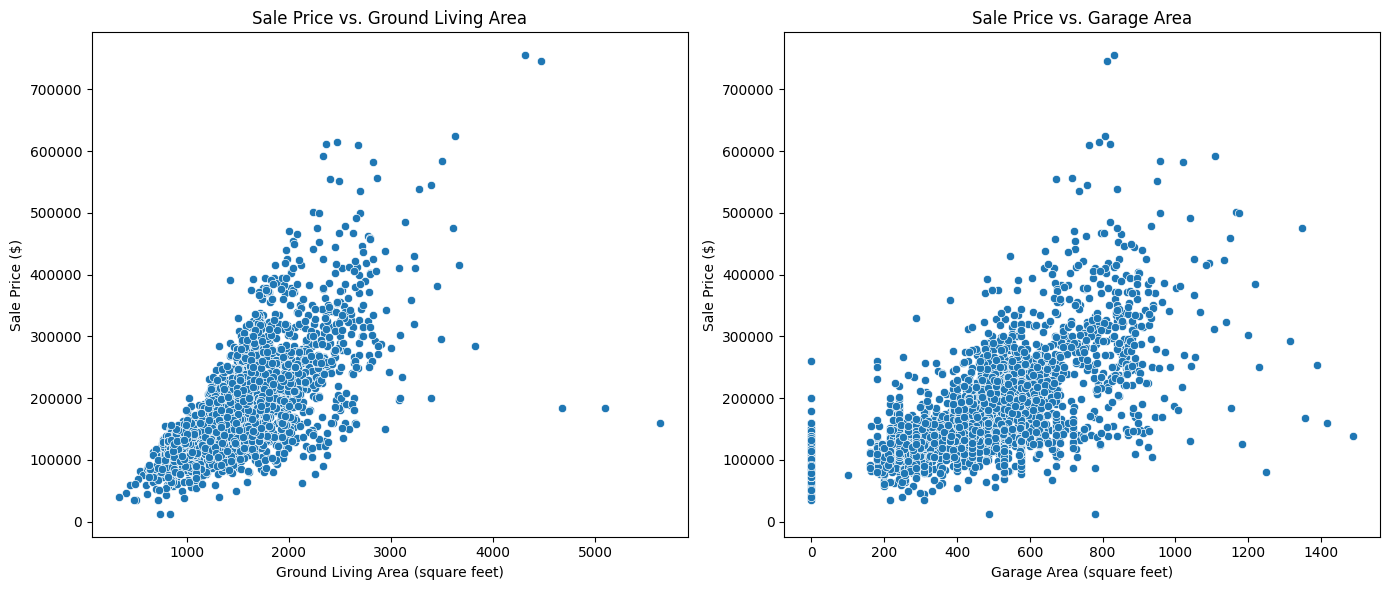

In [10]:
# Explore relationships between the independent and dependent variables
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Create the first scatter plot that shows the relationship between
# 'Sale_Price' and 'Gr_Liv_Area'.
sns.scatterplot(x='Gr_Liv_Area', y='Sale_Price', data=ames_df, ax=ax[0])
ax[0].set_title('Sale Price vs. Ground Living Area')
ax[0].set_xlabel('Ground Living Area (square feet)')
ax[0].set_ylabel('Sale Price ($)')

# Create the second scatter plot that shows the relationship between
# 'Sale_Price' and 'Garage_Area'.
sns.scatterplot(x='Garage_Area', y='Sale_Price', data=ames_df, ax=ax[1])
ax[1].set_title('Sale Price vs. Garage Area')
ax[1].set_xlabel('Garage Area (square feet)')
ax[1].set_ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

From the information given at the top of this Jupyter notebook, the sale price is recorded in dollars and all the area measurements ('Gr_Liv_Area' and 'Garage_Area') are in square feet. There seems to be outliers in the data, which is to be expected, since we are working with sales prices of houses. Since extremely high house prices can be found in the real world it can be assumed that these outliers might not necessarily be data entry errors. Therefore I will not remove the outliers from the dataset.

In [11]:
# Create a training and test set with a 75:25 split ratio
# Use the same random seed for reproducibility.
rseed = 23
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,  random_state=rseed)

print ("Training data:", X_train.shape, y_train.shape)
print ("Test data:", X_test.shape, y_test.shape)

Training data: (2192, 2) (2192,)
Test data: (731, 2) (731,)


From the two scatterplots above and the data description (ames_df.describe()) done at the top, it looks like 'Gr_Liv_Area' can be much larger than 'Garage_Area'.
Therefore scaling will be beneficial for this dataset because the independent variables ('Gr_Liv_Area' and 'Garage_Area') are on different scales. 

To address the different scales of the two variables ('Gr_Liv_Area' and 'Garage_Area'), the data needs to be standardized to bring them to a common scale while maintaining their distribution properties.

For Linear Regression, scaling features doesn't actually change the R-squared score or mean squared error value, it only changes the coefficients.
Without scaling, 'Gr_Liv_Area' would have a much smaller coefficient than a binary variable, making it hard to see which feature is more important. With scaling, the feature with the larger absolute coefficient is the more influential predictor.

In [12]:
# Fit the scaler on the train data.
scaler = StandardScaler()
scaler.fit(X_train)

# Apply the scaler on train and test data.
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'

# Initialize the multiple linear regression model.
multi_reg_model = LinearRegression()

# Fit the multiple linear regression model to the training data.
multi_reg_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# Print the model intercept and coefficients
print('Intercept: ', multi_reg_model.intercept_)
print('\nCoefficients: ', multi_reg_model.coef_)

# Calculate unscaled coefficients (inverse transform coefficients).
original_coeffs = multi_reg_model.coef_ / scaler.scale_
print('\nOriginal Inverse Coefficients (Unscaled Coefficients): ', original_coeffs)

Intercept:  182311.78832116787

Coefficients:  [43273.90184811 30622.76251707]

Original Inverse Coefficients (Unscaled Coefficients):  [ 84.95069263 143.1295074 ]


In [15]:
# Generate predictions for the test set
predictions = multi_reg_model.predict(X_test)
predictions[0:5]

array([352471.2997495 , 189294.69587556, 222300.87672981, 152773.09121012,
       192955.32614706])

In [16]:
# Evaluate the model
# Calculating the mean squared error value.
mse_value = mean_squared_error(y_test, predictions)
print("\nMean Squared Error (MSE):", round(mse_value, 4))

# Calculating the root mean squared error value.
rmse_value = np.sqrt(mse_value)
print("\nRoot Mean Squared Error (RMSE):", round(rmse_value, 4))

# Computing R-squared score for the model on the test set.
r2 = r2_score(y_test, predictions)
print("\nR-squared Score: ", round(r2, 4))


Mean Squared Error (MSE): 2215882916.9594

Root Mean Squared Error (RMSE): 47073.1656

R-squared Score:  0.5988


The MSE and RMSE values seems to be very high. 
The MSE value indicates the average squared difference between the predicted and actual sale price values. 
The seemingly high MSE value of 2 215 882 912.9594 (roughly 2.2 billion) indicates that the model does not predict the sale prices perfectly. 

However considering we are predicting sale prices for houses, the large MSE and RMSE values can be regarded as reasonable.    
The Root Mean Squared Error (RMSE) of approximately 47 073 indicates that, on average, the model's predictions are off by this amount ($47 073) from the actual sale prices in the test set.

The R-squared score of 0.5988 indicates that approximately 59.88% of the variance in the 'Sale_Price' data (dependent variable) is explained by the independent variables (feature matrix) in the model. Thus, about 40% of the variance in the 'Sale_Price' data (target/dependent variable (y)) cannot be explained by the independent variables (feature matrix (X)).

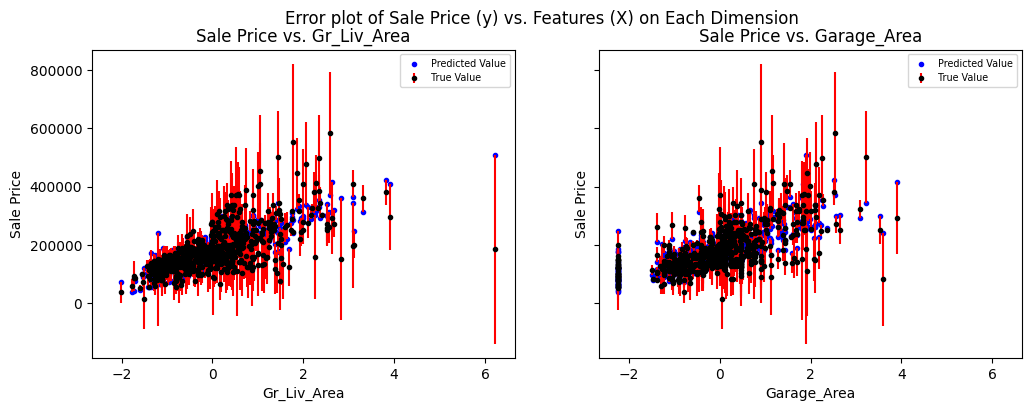

In [17]:
# Generate an error plot.
# Plot subplots for each of the features in X_test.
fig, ax = plt.subplots(1, X_test.shape[1], sharey=True, sharex=True, figsize=(12, 4))
fig.suptitle("Error plot of Sale Price (y) vs. Features (X) on Each Dimension")

# Get the absolute error values for the error bars.
error_bar_values = np.abs(y_test.values - predictions)

# Define feature names to be used for the xlabel of each plot.
feature_names = ['Gr_Liv_Area', 'Garage_Area']

# Plot data, predicted values, and error bars.
# Using a for loop and enumerate() to create error plots for each
# feature in X_test.
for i, feature in enumerate(feature_names):
    ax[i].errorbar(X_test[:, i], y_test, yerr=error_bar_values, fmt='.k', ecolor='red', label='True Value')
    ax[i].scatter(X_test[:, i], predictions, c='b', marker='.', label='Predicted Value')
    ax[i].set_xlabel(feature)
    ax[i].set_ylabel('Sale Price')
    ax[i].set_title(f"Sale Price vs. {feature}")
    ax[i].legend(loc='best', fontsize='x-small')

From the error plot above the red lines indicate the error of the prediction from the actual observations. The black dots represent true values, and the blue dots represent predicted values. The red error line represents the distance deviated from the true values. The red line either side of the black dot shows that the error may be within that line, either above or below.

From the error plot above, it looks like most of the predicted vaules (blue dots) are close to the true values (black dots), however the predicted values for the outliers can be further away from the true values. The red error lines are not extremely long which can suggest that the model fit our observations relatively well.

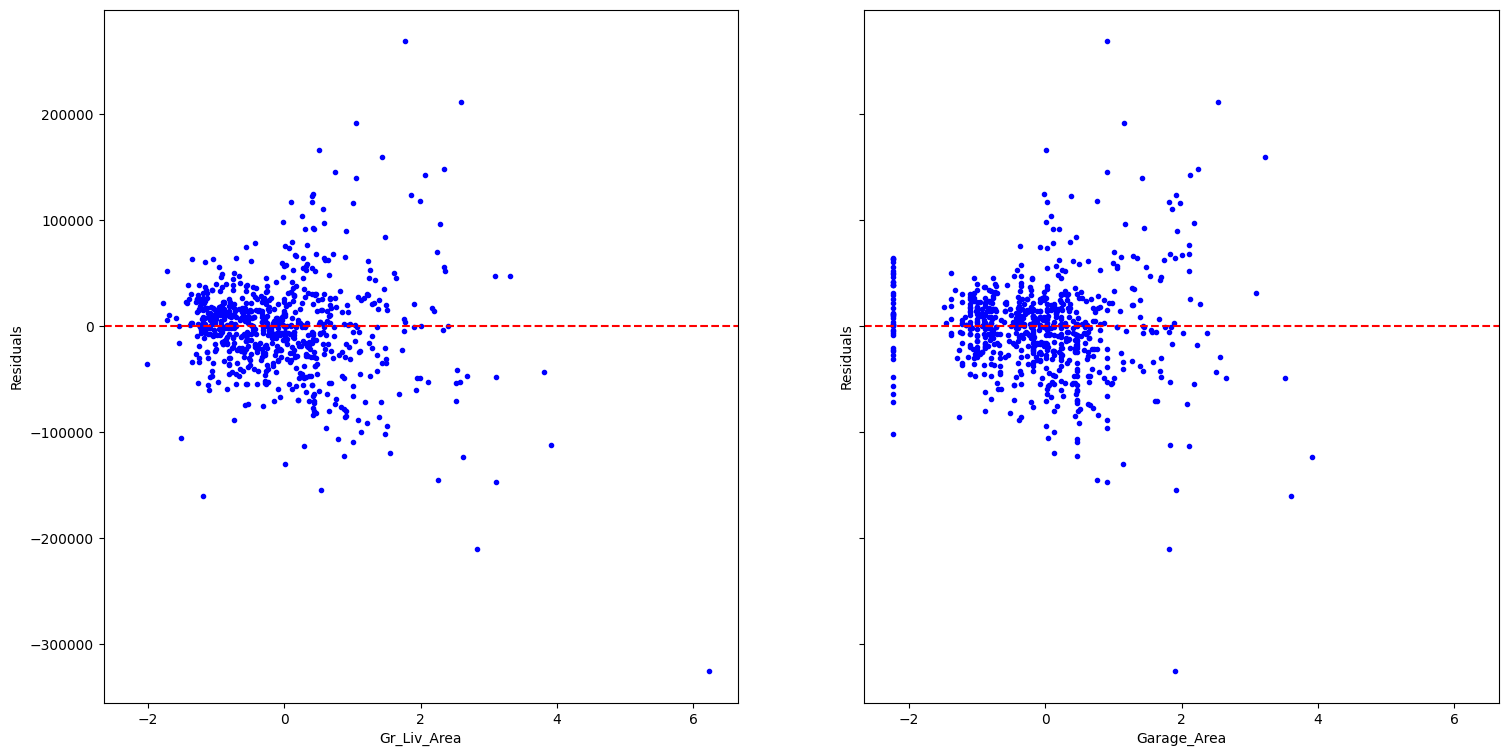

In [18]:
# Generate a residual plot for each feature to visualize the difference
# between true values and predicted values in the test set.
fig, ax = plt.subplots(1, X_test.shape[1], sharey=True, sharex=True, figsize=(18, 9))
residuals = y_test - predictions

# Using a for loop and enumerate() to create residual plots for each
# feature in X_test.
for i, feature in enumerate(feature_names):
    ax[i].scatter(X_test[:,i], residuals,c='b', marker='.')
    ax[i].set_xlabel(feature)
    ax[i].set_ylabel('Residuals')
    ax[i].axhline(y=0, color='r', linestyle="--")

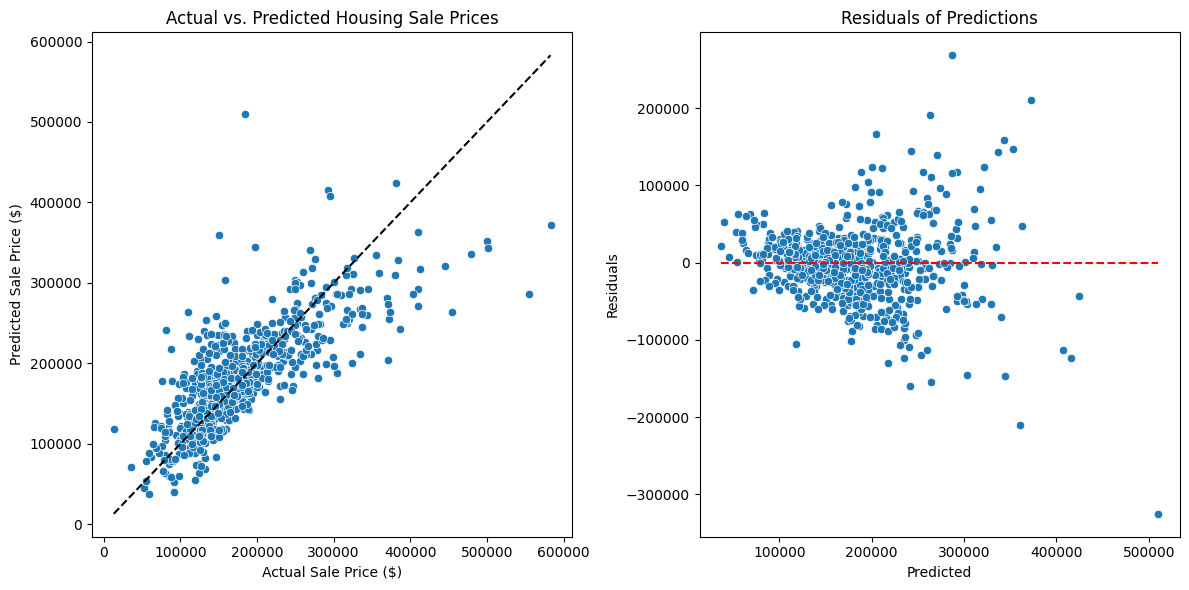

In [19]:
# Generate a plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Plotting the actual vs predicted values.
sns.scatterplot(x=y_test, y=predictions, ax=ax[0])
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--k')
ax[0].set_xlabel('Actual Sale Price ($)')
ax[0].set_ylabel('Predicted Sale Price ($)')
ax[0].set_title('Actual vs. Predicted Housing Sale Prices')

# Residuals plot.
residuals = y_test - predictions
sns.scatterplot(x=predictions, y=residuals, ax=ax[1])
ax[1].hlines(y=0, xmin=predictions.min(), xmax=predictions.max(), colors='red', linestyles='--')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Residuals')
ax[1].set_title('Residuals of Predictions')
plt.tight_layout()
plt.show()

The first plot shows a scatter plot of actual vs. predicted house sale prices. Ideally, the points should fall along the diagonal line if the predictions are perfect. Since the points does not fall perfectly along the diagonal line it means the predictions is not perfectly accurate. But the points are also not that far from the diagonal line which means that the predictions is relatively accurate.

The second plot, the residuals plot, helps in understanding the variance in the predictions. Residuals are the differences between the actual and predicted values. If the model is fitted well, the residuals should be randomly scattered around the horizontal line (y=0). In this case the residuals are mostly scattered randomly around the horizontal line, however the data is scattered a bit more to the left side of the graph, which could mean the model is not perfect but still moderately good.

In [20]:
# Print the coefficients.
# Using np.median to calculate the median of the predictions.
median_value_prediction = np.median(predictions)
print(f"The median of the predicted values is: {median_value_prediction}")

# Get the standard deviation used during scaling.
stds = scaler.scale_

# Calculate unscaled coefficients (inverse transform coefficients)
# (Price change per 1 square foot).
unscaled_coefs = multi_reg_model.coef_ / stds

# Using a for loop and a zip() function to print each feature and its
# corresponding coefficient (Scaled and Unscaled Coefficient).
for feature, coef, unsc_coef in zip(X.columns, multi_reg_model.coef_, unscaled_coefs):
    print(f"\n{feature}:")
    print(f"  - Scaled Coefficient (Importance): {coef:.2f}")
    print(f"  - Unscaled Coefficient (Price per square feet): {unsc_coef:.2f}")

The median of the predicted values is: 171717.09566646643

Gr_Liv_Area:
  - Scaled Coefficient (Importance): 43273.90
  - Unscaled Coefficient (Price per square feet): 84.95

Garage_Area:
  - Scaled Coefficient (Importance): 30622.76
  - Unscaled Coefficient (Price per square feet): 143.13


### Interpret coefficients in the context of the prediction:

* **The unscaled coefficients:**

The unscaled coefficient for 'Gr_Liv_Area' is approximately 84.95   
This means that for every **one-square-foot** increase in the ground living area, the predicted sale price increases by about $84.95 (assuming the garage area remains constant). 

The unscaled coefficient for 'Garage_Area' is approximately 143.13   
This means that for every **one-square-foot** increase in the garage area, the predicted sale price increases by about $143.13 (assuming the ground living area remains constant). 

* **The scaled coefficients:**

The scaled coefficients show that 'Gr_Liv_Area'  has a stronger positive impact on the 'Sale_Price' than 'Garage_Area', which is in line with the initial findings from the EDA.

The scaled coefficient for 'Gr_Liv_Area' is approximately 43 273.90 which means that for every **one standard deviation** increase in the ground living area, the predicted sale price increases by about $43 273.90 (assuming the garage area remains constant). 

Similarly for every **one standard deviation** increase in the garage area, the predicted sale price increases by about $30 622.76 (assuming the ground living area remains constant). 

### Summarise findings

The exploratory data analysis revealed a strong, positive correlation between the 'Sale_Price' of the houses and both 'Gr_Liv_Area' and 'Garage_Area'. Larger houses and houses with larger garages tend to have higher sale prices.
The multiple linear regression model was built using a training set with these two variables, and the model's performance was evaluated on a test set.

The model's performance, as measured by the root mean squared error (RMSE) of 47 073, indicates that on average, the predictions are off by about $47 073 from the actual sale price. While this value seems high, but considering the wide range of sale prices, which is in the range of hundreds of thousands it's an expected outcome and thus the RMSE value can actually be considered relatively low. 

Other variables, such as the total size of basement area in square feet (Total_Bsmt_SF) and size of the first floor in square feet (First_Flr_SF) also had high correlations with the sale price of the house (Sale_Price), seen from the exploratory data analysis, and including them would likely improve the model's accuracy.

The error plots and residual plot also suggest that the model's errors are relatively small and randomly distributed. 

The model coefficients confirm the initial findings from the EDA, highlighting that both ground living area and garage area are strong predictors of sale price for houses, with the ground living area having a slightly larger impact per square foot in this model.

In conclusion, this model provides a good starting point for predicting sale prices based on these two features, but incorporating more variables could likely improve its accuracy.